в функцию CrossEntropyLoss можно передавать как OneHot вектор, так и обычное целое число, которое автоматом преобразуется в OneHot вектор

например, цифра 7 будет автоматически преобразована вектор:  [0, 0, 0, 0, 0, 0, 0, 1, 0, 0]. Причем длина вектора зависит от кол-ва нейронов выходного слоя

контролирует эквивалентность размеров

ResNet(там вроде картинки 224*224), это как раз делает изображения единых размеров

```python
# Преобразуем изображения на основе модуля v2
size = 224

transform_v2 = v2.Compose([
    v2.ToImage(),
    v2.Resize(256),
    v2.CenterCrop(size),
    v2.ToDtype(dtype=torch.float32, scale=True),
    v2.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))]
)
```

из документации:

```python
transforms = v2.Compose([
    v2.ToImage(),  # Convert to tensor, only needed if you had a PIL image
    v2.ToDtype(torch.uint8, scale=True),  # optional, most input are already uint8 at this point
    # ...
    v2.RandomResizedCrop(size=(224, 224), antialias=True),  # Or Resize(antialias=True)
    # ...
    v2.ToDtype(torch.float32, scale=True),  # Normalize expects float input
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
```

In [15]:
from PIL import Image
import torchvision.transforms as tfs
import matplotlib.pyplot as plt
import torchvision.transforms.v2 as tfs_v2

img_pil = Image.new(mode="RGB", size=(128, 128), color=(0, 128, 255))

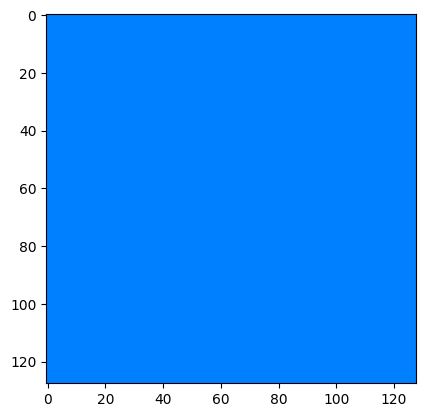

In [16]:
# Что бы увидеть картинку в формате PIL добавьте в код:
plt.imshow(img_pil)
plt.show()

In [ ]:
# transforms = tfs.ToTensor()
transforms = tfs.PILToTensor()
img = transforms(img_pil)

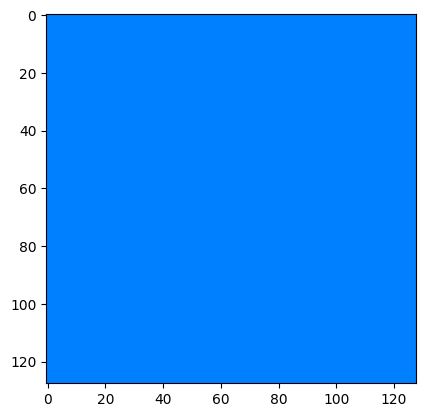

In [20]:
# Но, потом мы создаём тензор img который уже так распечатать не получится(plt.show())
# У нас тензоры  в формате (C, H, W) (каналы-3, высота-128, ширина-128), 
# а matplotlib ожидает изображения в формате (H, W, C) (высота, ширина, каналы). 
# Поэтому перед выводом изображения необходимо выполнить перестановку осей
img_for_plot = img.permute(1, 2, 0)
plt.imshow(img_for_plot)

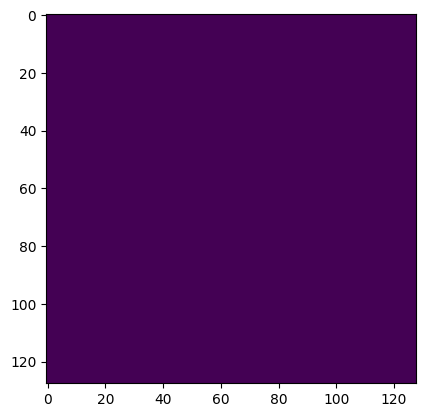

In [ ]:
from PIL import Image
import torchvision.transforms as tfs
# import torchvision.transforms.v2 as tfs_v2 - недоступен на Stepik

img_pil = Image.new(mode="RGB", size=(128, 128), color=(0, 128, 255))

# здесь продолжайте программу
transforms = tfs.Compose([tfs.Grayscale(), # преобразование в градации серого
                          tfs.ToTensor(), # преобразование из PIL в тензор PyTorch
                          tfs.Normalize(mean=(0.5,), std=(1.0,))]) # нормализацию данных со средним 0.5 (mean=0.5) и единичным стандартным отклонением (std=1.0)
img = transforms(img_pil)

img_for_plot = img.permute(1, 2, 0)
plt.imshow(img_for_plot)

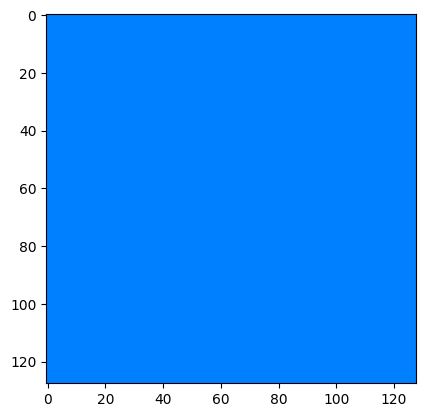

In [ ]:
from PIL import Image
import torchvision.transforms as tfs
# import torchvision.transforms.v2 as tfs_v2 - недоступен на Stepik

img_pil = Image.new(mode="RGB", size=(128, 128), color=(0, 128, 255))

# здесь продолжайте программу
transforms = tfs.Compose([tfs.CenterCrop(64), #  - обрезка изображения относительно центра до размеров 64x64;
                          tfs.Resize(128), # - масштабирование изображения до размеров 128x128;
                          tfs.ToTensor()]) # - преобразование PIL в тензор.
img = transforms(img_pil)

img_for_plot = img.permute(1, 2, 0)
plt.imshow(img_for_plot)

In [2]:
import torch

t_rnd = torch.randint(-3, 5, (100, ), dtype=torch.float32) # значения этого тензора в программе не менять

t_mean = torch.mean(t_rnd)

t_max = torch.max(t_rnd[:5])

t_min = torch.min(t_rnd[-3:])

print(t_rnd)
print(t_mean, t_max, t_min)

tensor([ 1.,  4.,  2.,  4.,  1.,  4.,  3., -1., -3., -1.,  1., -2.,  1., -1.,
         0.,  2.,  3.,  2., -2., -2.,  2., -1., -2.,  1.,  0.,  1.,  4.,  1.,
         0.,  3.,  2., -1.,  1., -2., -2., -2., -2., -1.,  2., -3., -3.,  3.,
        -3., -2.,  4., -3., -2.,  4.,  0.,  4., -3.,  1., -2.,  4.,  3., -2.,
         2., -3., -2.,  0.,  3.,  3.,  4.,  3.,  3.,  3.,  3., -1.,  3.,  1.,
         4.,  0., -1., -1., -1.,  4.,  0., -2.,  1.,  2.,  3., -1.,  2.,  4.,
        -3., -1.,  0.,  0.,  1.,  4.,  3.,  1.,  4., -3.,  1.,  4.,  4., -2.,
         1.,  0.])
tensor(0.7000) tensor(4.) tensor(-2.)
